In [1]:
#@title Install pre-requisites
!pip install mujoco
!pip install mujoco_mjx
!pip install brax

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 67.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 71.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 709.8/709.8 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.1/344.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 523.1/523.1 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: orbax-checkpoint
    Found existing installation: orbax-checkpoint 0.11.16
    Uninstalling orbax-checkpoint-0.11.16:
      Successfully uninstalled orbax-checkpoint-0.11.16


In [2]:
!pip install wandb

In [3]:
!wandb login f0b1d6e401bba640c9652770100579b8727dc2fd

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [4]:
# @title Check if MuJoCo installation was successful

import distutils.util
import os
import subprocess

if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.'
  )

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco

  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".'
  )

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

Wed Aug 27 22:56:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# @title Import packages for plotting and creating graphics
import json
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.
print("Installing mediapy:")
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

Installing mediapy:


In [6]:
# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
#from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

In [7]:
# ================================================================
# 0. 依赖
# ================================================================
import jax, jax.numpy as jnp
from flax import linen as nn
from flax.linen.initializers import lecun_normal, zeros
from typing import Optional
from brax.training import networks, distribution, types   

# ================================================================
# 1. MaskedDense（可选稀疏投影）
# ================================================================
class MaskedDense(nn.Module):
    features: int
    mask: Optional[jnp.ndarray] = None   # bool array (in_dim, out_dim)
    use_bias: bool = True
    kernel_init: nn.initializers.Initializer = lecun_normal()
    bias_init: nn.initializers.Initializer = zeros

    @nn.compact
    def __call__(self, x):
        k = self.param('kernel', self.kernel_init, (x.shape[-1], self.features))
        if self.mask is not None:
            k = k * self.mask
        y = x @ k
        if self.use_bias:
            b = self.param('bias', self.bias_init, (self.features,))
            y = y + b
        return y

# ================================================================
# 2. CfCCell  —— 支持多模式
# ================================================================
def lecun_tanh(x):
    return 1.7159 * jnp.tanh(0.666 * x)

class CfCCell(nn.Module):
    units: int
    mode: str = "default"               # default / pure / no_gate / mixed_memory
    activation: str = "lecun_tanh"      # "relu" | "tanh" | …
    backbone_units: int = 128
    backbone_layers: int = 1
    backbone_dropout: float = 0.0
    proj_size: Optional[int] = None     # 若不为 None，则将输出再投影
    sparsity_mask: Optional[jnp.ndarray] = None  # 用于 MaskedDense

    @nn.compact
    def __call__(self, x_t, h_prev, ts=1.0, deterministic: bool = True):
        """
        x_t : (B, F)
        h_prev : (B, H)
        ts : broadcastable scalar 或 (B,) —— 两个时间步间隔
        """
        # ---------- backbone ------------------------------------------------
        z = jnp.concatenate([x_t, h_prev], -1)            # (B, F+H)
        act_fn = lecun_tanh if self.activation == "lecun_tanh" else getattr(jax.nn, self.activation)

        for _ in range(self.backbone_layers):
            z = nn.Dense(self.backbone_units)(z)
            z = act_fn(z)
            if self.backbone_dropout > 0:
                z = nn.Dropout(rate=self.backbone_dropout)(z, deterministic=deterministic)

        # ---------- mode 分支 ----------------------------------------------
        if self.mode == "pure":
            h_new = act_fn(nn.Dense(self.units)(z))

        else:  # default / no_gate / mixed_memory
            ff1 = act_fn(nn.Dense(self.units)(z))
            ff2 = act_fn(nn.Dense(self.units)(z))

            # time gate
            t_a = nn.Dense(self.units)(z)
            t_b = nn.Dense(self.units)(z)

            ts_ = jnp.asarray(ts)
            if ts_.ndim == 0:
                ts_ = ts_[None, None]            # (1,1)
            elif ts_.ndim == 1:
                ts_ = ts_[:, None]               # (B,1)

            g = jax.nn.sigmoid(t_a * ts_ + t_b)  # (B,H)

            if self.mode == "no_gate":
                h_new = ff1 * (1.0 - g) + g * ff2
            elif self.mode == "mixed_memory":
                mem = jax.nn.sigmoid(nn.Dense(self.units)(z))
                h_new = mem * h_prev + (1.0 - mem) * (ff1 * (1 - g) + g * ff2)
            else:  # default
                h_new = ff1 * (1.0 - g) + g * ff2

        # ---------- optional projection ------------------------------------
        if self.proj_size is not None and self.proj_size < self.units:
            if self.sparsity_mask is not None:
                # 稀疏投影
                h_proj = MaskedDense(
                    self.proj_size,
                    mask=self.sparsity_mask,
                    use_bias=True
                )(h_new)
            else:
                # 普通全连接投影
                h_proj = nn.Dense(self.proj_size)(h_new)
            return h_proj, h_new          # 投影输出、完整隐藏态
        else:
            return h_new, h_new


# ================================================================
# 3. Step & Scan (参数共享)
# ================================================================
class Step(nn.Module):
    units: int
    cell_cfg: dict

    def setup(self):
        self.cell = CfCCell(units=self.units, **self.cell_cfg)

    def __call__(self, h_prev, inp):
        x_t, dt_t = inp
        y, h_new = self.cell(x_t, h_prev, dt_t, deterministic=self.is_mutable_collection('dropout'))
        return h_new, y

ScanStep = nn.scan(
    Step,
    variable_broadcast='params',
    split_rngs={'params': False, 'dropout': True},
    in_axes=0, out_axes=0
)

# ================================================================
# 4. CfC  (sequence wrapper)
# ================================================================
class CfC(nn.Module):
    input_size: int
    units: int
    return_sequences: bool = True
    batch_first: bool = True

    # 透传给 CfCCell 的可选参数
    mode: str = "default"
    activation: str = "lecun_tanh"
    backbone_units: int = 128
    backbone_layers: int = 1
    backbone_dropout: float = 0.0
    proj_size: Optional[int] = None
    sparsity_mask: Optional[jnp.ndarray] = None

    def setup(self):
        cell_cfg = dict(
            mode=self.mode,
            activation=self.activation,
            backbone_units=self.backbone_units,
            backbone_layers=self.backbone_layers,
            backbone_dropout=self.backbone_dropout,
            proj_size=self.proj_size,
            sparsity_mask=self.sparsity_mask,
        )
        self.rnn = ScanStep(units=self.units, cell_cfg=cell_cfg)

    def __call__(self, x, timespans=None, deterministic: bool = True):
        """
        x : (B, T, F) if batch_first else (T, B, F)
        timespans : None or same leading shape without F
        """
        if not self.batch_first:             # 保证时间维在 dim=1
            x = jnp.swapaxes(x, 0, 1)
            if timespans is not None:
                timespans = jnp.swapaxes(timespans, 0, 1)

        B, T, _ = x.shape
        if timespans is None:
            timespans = jnp.ones((B, T))

        h0 = jnp.zeros((B, self.units))
        xs = (x.swapaxes(0, 1), timespans.swapaxes(0, 1))   # time-major for scan
        h_final, y_T = self.rnn(h0, xs, mutable=['dropout'] if not deterministic else False)

        y = y_T.swapaxes(0, 1)                              # (B, T, H)
        if not self.return_sequences:
            y = y[:, -1, :]                                 # (B, H)

        if not self.batch_first and self.return_sequences:
            y = jnp.swapaxes(y, 0, 1)

        return y, h_final

# ================================================================
# 5. CfCWrapper（与你现有代码接口一致）
# ================================================================
class CfCWrapper(nn.Module):
    input_size: int
    hidden_size: int
    return_sequences: bool = False
    # 你可以把下面这些参数暴露成 CfCWrapper 的字段
    mode: str = "default"
    proj_size: Optional[int] = None

    def setup(self):
        self.cfc = CfC(
            input_size=self.input_size,
            units=self.hidden_size,
            return_sequences=self.return_sequences,
            batch_first=True,
            mode=self.mode,
            backbone_units=128,
            backbone_layers=2,
            proj_size=self.proj_size,
        )

    def __call__(self, x, deterministic: bool = True):
        """
        x : (B, F)  or (B, T, F)
        若传入 2-D，则自动扩展一个 T=1 维
        """
        added_dim = False
        if x.ndim == 2:
            x = x[:, None, :]
            added_dim = True

        y, _ = self.cfc(x, deterministic=deterministic)   # y: (B,T,H) or (B,H)
        if not self.return_sequences and added_dim:
            return y                                      # (B,H)
        return y

# ================================================================
# 6. Quick unit-test
# ================================================================

rng = jax.random.PRNGKey(0)
dummy = jnp.zeros((2, 10, 30))          # (B,T,F)

model = CfC(input_size=30, units=64, mode="default")
params = model.init(rng, dummy)
y, h = model.apply(params, dummy)
print("default  y:", y.shape, "h:", h.shape)

model_pure = CfC(input_size=30, units=64, mode="pure", return_sequences=False)
y_p, h_p = model_pure.apply(model_pure.init(rng, dummy), dummy)
print("pure     y:", y_p.shape, "h:", h_p.shape)

model_proj = CfC(input_size=30, units=64, proj_size=16)
params_proj = model_proj.init(rng, dummy)
y_proj, h_proj = model_proj.apply(params_proj, dummy)
print("proj     y:", y_proj.shape, "h:", h_proj.shape)


# ================================================================
# 5. PPO 网络构造
# ================================================================
@struct.dataclass
class PPONetworks:
    policy_network: networks.FeedForwardNetwork
    value_network: networks.FeedForwardNetwork
    parametric_action_distribution: distribution.ParametricDistribution


def make_ppo_networks(
    observation_size: types.ObservationSize,
    action_size: int,
    preprocess_observations_fn: types.PreprocessObservationFn = (
        types.identity_observation_preprocessor
    ),
    # 下面这些在 train() 里会被传进来 —— 先接住再按需使用
    policy_hidden_layer_sizes=(64,),
    value_hidden_layer_sizes=(64,),
    activation=nn.swish,
    policy_obs_key: str = "state",
    value_obs_key: str = "state",
    distribution_type: str = "tanh_normal",
    **unused_kwargs,                       # 兜底：万一以后又多新参数
):
    """Returns PPONetworks whose torso是 CfC."""

    # 1) 动作分布 --------------------------------------------------------
    if distribution_type == "normal":
        pad = distribution.NormalDistribution(event_size=action_size)
    elif distribution_type == "tanh_normal":
        pad = distribution.NormalTanhDistribution(event_size=action_size)
    else:
        raise ValueError("unsupported distribution type")

    # 2) 观测维度 --------------------------------------------------------
    if isinstance(observation_size, dict):
        obs_dim_policy = int(observation_size[policy_obs_key][0])
        obs_dim_value = int(observation_size[value_obs_key][0])
    else:
        obs_dim_policy = int(observation_size)
        obs_dim_value = int(observation_size)

    # ------------------------------------------------ Policy Net -------
    class PolicyNet(nn.Module):
        @nn.compact
        def __call__(self, x):
            # x 可能是 (F,), (B,F) 或 (T,B,F)……
            orig_shape = x.shape[:-1]                 # 前置批维
            x_flat = x.reshape(-1, x.shape[-1])       # (N, F)
    
            h = CfCWrapper(
                input_size=x.shape[-1],
                hidden_size=policy_hidden_layer_sizes[0],
                return_sequences=False,
            )(x_flat)                                 # (N, H)
    
            h = h.reshape(*orig_shape, -1)            # (..., H)
            logits = nn.Dense(pad.param_size)(h)      # (..., param_size)
            return logits


    class ValueNet(nn.Module):
        @nn.compact
        def __call__(self, x):
            orig_shape = x.shape[:-1]
            x_flat = x.reshape(-1, x.shape[-1])
    
            h = CfCWrapper(
                input_size=x.shape[-1],
                hidden_size=value_hidden_layer_sizes[0],
                return_sequences=False,
            )(x_flat)                                 # (N, H)
    
            h = h.reshape(*orig_shape, -1)            # (..., H)
            v = nn.Dense(1)(h)                        # (..., 1)
            return jnp.squeeze(v, axis=-1)            # (...,)


    # -------- FeedForwardNetwork 包装 -------------------------------
    def _unwrap(p):
        while isinstance(p, (tuple, list)) and len(p) == 2:
            p = p[1]
        return p

    # policy
    def policy_init(rng):
        dummy = jnp.zeros((1, obs_dim_policy))
        return (None, PolicyNet().init(rng, dummy))

    def policy_apply(norm_params, net_params, obs):
        if preprocess_observations_fn is not None:
            obs = preprocess_observations_fn(obs, norm_params)
        x = obs[policy_obs_key] if isinstance(obs, dict) else obs
        return PolicyNet().apply(_unwrap(net_params), x)

    # value
    def value_init(rng):
        dummy = jnp.zeros((1, obs_dim_value))
        return (None, ValueNet().init(rng, dummy))

    def value_apply(norm_params, net_params, obs):
        if preprocess_observations_fn is not None:
            obs = preprocess_observations_fn(obs, norm_params)
        x = obs[value_obs_key] if isinstance(obs, dict) else obs
        return ValueNet().apply(_unwrap(net_params), x)

    return PPONetworks(
        policy_network=networks.FeedForwardNetwork(policy_init, policy_apply),
        value_network=networks.FeedForwardNetwork(value_init, value_apply),
        parametric_action_distribution=pad,
    )
# ================================================================
# 6. Quick sanity-check
# ================================================================
nets = make_ppo_networks(30, 8)
rng = jax.random.PRNGKey(0)
pi_params = nets.policy_network.init(rng)
v_params  = nets.value_network.init(rng)

dummy_obs = jnp.zeros((4, 30))
logits = nets.policy_network.apply(*pi_params, dummy_obs)
values = nets.value_network.apply(*v_params , dummy_obs)

print("logits shape:", logits.shape)   # (4,1,param_size)
print("values shape:", values.shape)   # (4,1)

nets = make_ppo_networks(30, 8)      # 30 = obs dim, 8 = action dim
rng  = jax.random.PRNGKey(0)

pi_params = nets.policy_network.init(rng)
dummy_obs = jnp.zeros((4, 128,30))      # (B,F)

logits = nets.policy_network.apply(*pi_params, dummy_obs)
print(logits.shape)                  # (4, param_size)  ← 无时间维


INFO:2025-08-27 22:56:14,369:jax._src.xla_bridge:924: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-08-27 22:56:14,382:jax._src.xla_bridge:924: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
/usr/local/lib/python3.11/dist-packages/flax/core/lift.py:310: RuntimeWarning: kwargs are not supported in scan, so "mutable" is(are) ignored
  warnings.warn(msg.format(name, ', '.join(kwargs.keys())), RuntimeWarning)


default  y: (2, 10, 64) h: (2, 64)
pure     y: (2, 64) h: (2, 64)
proj     y: (2, 10, 16) h: (2, 64)
logits shape: (4, 16)
values shape: (4,)
(4, 128, 16)


In [8]:
#@title Install MuJoCo Playground
!pip install playground

/usr/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 67.4 MB/s eta 0:00:00:00:0100:01


In [9]:
#@title Import The Playground

from mujoco_playground import wrapper
from mujoco_playground import registry

mujoco_menagerie not found. Downloading...


Cloning mujoco_menagerie: ██████████| 100/100 [00:24<00:00]


Checking out commit 14ceccf557cc47240202f2354d684eca58ff8de4
Successfully downloaded mujoco_menagerie


# Locomotion

MuJoCo Playground contains a host of quadrupedal and bipedal environments (all listed below after running the command).

In [10]:
registry.locomotion.ALL_ENVS

('ApolloJoystickFlatTerrain',
 'BarkourJoystick',
 'BerkeleyHumanoidJoystickFlatTerrain',
 'BerkeleyHumanoidJoystickRoughTerrain',
 'G1JoystickFlatTerrain',
 'G1JoystickRoughTerrain',
 'Go1JoystickFlatTerrain',
 'Go1JoystickRoughTerrain',
 'Go1Getup',
 'Go1Handstand',
 'Go1Footstand',
 'H1InplaceGaitTracking',
 'H1JoystickGaitTracking',
 'Op3Joystick',
 'SpotFlatTerrainJoystick',
 'SpotGetup',
 'SpotJoystickGaitTracking',
 'T1JoystickFlatTerrain',
 'T1JoystickRoughTerrain')

# Quadrupedal

Let's jump right into quadrupedal locomotion! While we have environments available for the Google Barkour and Boston Dynamics Spot robots, the Unitree Go1 environment contains the most trainable policies that were transferred onto the real robot. We'll go right ahead and show a few policies using the Unitree Go1!

First, let's train a joystick policy, which tracks linear and yaw velocity commands.

In [11]:
env_name = 'Go1JoystickFlatTerrain'
env = registry.load(env_name)
env_cfg = registry.get_default_config(env_name)

In [12]:
env_cfg

Kd: 0.5
Kp: 35.0
action_repeat: 1
action_scale: 0.5
command_config:
  a:
  - 1.5
  - 0.8
  - 1.2
  b:
  - 0.9
  - 0.25
  - 0.5
ctrl_dt: 0.02
episode_length: 1000
history_len: 1
noise_config:
  level: 1.0
  scales:
    gravity: 0.05
    gyro: 0.2
    joint_pos: 0.03
    joint_vel: 1.5
    linvel: 0.1
pert_config:
  enable: false
  kick_durations:
  - 0.05
  - 0.2
  kick_wait_times:
  - 1.0
  - 3.0
  velocity_kick:
  - 0.0
  - 3.0
reward_config:
  max_foot_height: 0.1
  scales:
    action_rate: -0.01
    ang_vel_xy: -0.05
    dof_pos_limits: -1.0
    energy: -0.001
    feet_air_time: 0.1
    feet_clearance: -2.0
    feet_height: -0.2
    feet_slip: -0.1
    lin_vel_z: -0.5
    orientation: -5.0
    pose: 0.5
    stand_still: -1.0
    termination: -1.0
    torques: -0.0002
    tracking_ang_vel: 0.5
    tracking_lin_vel: 1.0
  tracking_sigma: 0.25
sim_dt: 0.004
soft_joint_pos_limit_factor: 0.95

## Joystick

Let's train the joystick policy and visualize rollouts:

In [13]:
from mujoco_playground.config import locomotion_params
ppo_params = locomotion_params.brax_ppo_config(env_name)
#ppo_params["num_timesteps"] = ppo_params["num_timesteps"] // 2

ppo_params

action_repeat: 1
batch_size: 256
discounting: 0.97
entropy_cost: 0.01
episode_length: 1000
learning_rate: 0.0003
max_grad_norm: 1.0
network_factory:
  policy_hidden_layer_sizes: &id001 !!python/tuple
  - 512
  - 256
  - 128
  policy_obs_key: state
  value_hidden_layer_sizes: *id001
  value_obs_key: privileged_state
normalize_observations: true
num_envs: 8192
num_evals: 10
num_minibatches: 32
num_resets_per_eval: 1
num_timesteps: 200000000
num_updates_per_batch: 4
reward_scaling: 1.0
unroll_length: 20

Domain randomization was used to make the policy robust to sim-to-real transfer. Certain environments in the Playground have domain randomization functions implemented. They're available in the registry and can be passed directly to brax RL algorithms. The [domain randomization](https://github.com/google-deepmind/mujoco_playground/blob/main/mujoco_playground/_src/locomotion/go1/randomize.py) function randomizes over friction, armature, center of mass of the torso, and link masses, amongst other simulation parameters.

In [14]:
registry.get_domain_randomizer(env_name)

<function mujoco_playground._src.locomotion.go1.randomize.domain_randomize(model: mujoco.mjx._src.types.Model, rng: jax.Array)>

In [15]:
# ------ wandb 相关 ------
import os, csv, numpy as np, wandb, jax.numpy as jnp
def wandb_init(run_name: str,
               hyper_params: dict,
               seed: int | None = None,
               project: str = 'brax-cfc'):
    cfg = dict(hyper_params)
    if seed is not None:
        cfg['seed'] = seed
    return wandb.init(project=project,
                      name=run_name,
                      config=cfg,
                      save_code=False)     # 不自动上传源码


In [16]:
from brax.training.agents.ppo.train import train as ppo_train
import inspect, textwrap, os
print('train 来自:', inspect.getfile(ppo_train))
print('signature :', inspect.signature(ppo_train))   # 这里会出现 log_frequency


train 来自: /usr/local/lib/python3.11/dist-packages/brax/training/agents/ppo/train.py
signature : (environment: brax.envs.base.Env, num_timesteps: int, max_devices_per_host: Optional[int] = None, wrap_env: bool = True, madrona_backend: bool = False, augment_pixels: bool = False, num_envs: int = 1, episode_length: Optional[int] = None, action_repeat: int = 1, wrap_env_fn: Optional[Callable[[Any], Any]] = None, randomization_fn: Optional[Callable[[brax.base.System, jax.Array], Tuple[brax.base.System, brax.base.System]]] = None, learning_rate: float = 0.0001, entropy_cost: float = 0.0001, discounting: float = 0.9, unroll_length: int = 10, batch_size: int = 32, num_minibatches: int = 16, num_updates_per_batch: int = 2, num_resets_per_eval: int = 0, normalize_observations: bool = False, reward_scaling: float = 1.0, clipping_epsilon: float = 0.3, gae_lambda: float = 0.95, max_grad_norm: Optional[float] = None, normalize_advantage: bool = True, network_factory: brax.training.types.NetworkFactor

In [17]:
##############################################
# ------------------- 全局缓冲区 -------------------
from datetime import datetime
import matplotlib.pyplot as plt
from IPython.display import clear_output

#超参数
randomizer = registry.get_domain_randomizer(env_name)
ppo_training_params = dict(ppo_params)
ppo_training_params.pop("network_factory", None)
step_stride = 40 * 8192        # 327_680
ppo_training_params.update({
    "entropy_cost":       1e-2,
    "discounting":        0.97,
    "max_grad_norm":      1.0,
    "normalize_observations": True,
    "reward_scaling":     1.0,
    "unroll_length":      40,
    "batch_size":         256,
    "num_envs":           8192,
    "num_minibatches":    32,
    "num_updates_per_batch": 4,
    "num_evals":          10,
    "num_resets_per_eval": 1,
      'log_training_metrics': True,          # 打开指标记录
    'training_metrics_steps': 327_680, 
    'clipping_epsilon' : 0.25,
# 每多少环境步推一次
})
seed = ppo_training_params.get('seed', 0)


# -------------------------------------------------
# 动态学习率：0-40M 用 3e-4，其后降到 3e-5
# -------------------------------------------------
import optax

# --- learning-rate schedule ---
lr_adapter = optax.join_schedules(
    schedules=[
        optax.constant_schedule(3e-4),   # 0–70 M
        optax.constant_schedule(1e-4),   # 70–90 M
        optax.constant_schedule(3e-5),   # 90 M+
    ],
    boundaries=[70_000_000, 90_000_000]
)
# 或更多段落/指数衰减都可以在这里组合





In [18]:
def wandb_init(run_name, hyper_params, seed=None, project='brax-cfc'):
    cfg = dict(hyper_params)
    if seed is not None:
        cfg['seed'] = seed
    return wandb.init(project=project,
                      name=run_name,
                      config=cfg,
                      save_code=False)

wandb_run = wandb_init(
    run_name = (f"818lr{ppo_training_params['learning_rate']}_"
                f"ent{ppo_training_params['entropy_cost']}_"
                f"bs{ppo_training_params['batch_size']}_"
                f"seed{seed}"),
    hyper_params = ppo_training_params,
    seed = seed
)


wandb: Currently logged in as: lihongyuanj (lihongyuanj-hohai-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


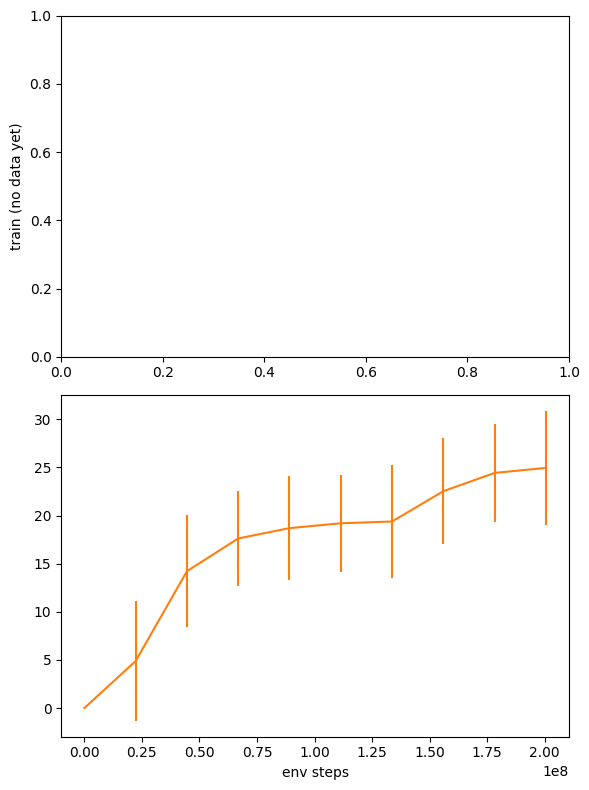

episode/length,▁▁▁▂▃▄▇██▇▅▆▂▂█▂▅▆▆▄▆▆▆▆▆▆▆▆▂▃█▇▆▆▇█▆█▇▇
episode/reward/action_rate,██▇▂▁▃▄▄▄█▇▆▆▆█▇▇▇██▇▇▇▆▆▆▇▆▆█▅▅▆█▇▅▆▆▆▆
episode/reward/ang_vel_xy,▆▆▆▆▆▁▆▃▃▃▁▃▄▇▆▇███████▇▇▇█▇▇█▇▇▇██▇▇▇█▇
episode/reward/dof_pos_limits,███▆█▇███▆▇██████▇▇▇████▆████▅▇▁▇▂█▄████
episode/reward/energy,▇▅▄▁▂▇▇█▇█▇█████▇▇▇█▆▇▆▆▇▅▄▃▅▄▁▃▃▃▃▆▄▃▃▃
episode/reward/feet_air_time,▄▄▄▄▄▄▃▃▃▁▂▄▃▃▃▄▃▃▃▃▄▃▄▄▃▄▄▄▄▄▅▇▇▇▆▅████
episode/reward/feet_clearance,███▅▄▁▁▂▁▂▅▄▆▅▅▇▇▇▆▆▆▇▇▅▆▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃
episode/reward/feet_height,███▇▇▆▂▁▂▇▂▅▄█▄▆▆█▆▆▆▆▆██▅▆▆▆▆▆▇█▇▇▆██▇▇
episode/reward/feet_slip,▇▇▇▆▆▄▄▄▃▂▁▄▄▇█▇▇█▇▇▇▇▇█████▆▇▆▆▆▆▇▆▆▆▇▆
episode/reward/lin_vel_z,▆▆▆▆▃▆▄▁▃▄▆▅▆▆▆█▇▇▇▇▇▆▆▇▇▇▆▆▇▆▆▅▄▅▅▅▅▆▃▅
episode/reward/orientation,▄▂▁▁▆▆▅█▅▃▆▅▄█▄▅▃▂▅▅▄▃▃▃▃▅▅▆▄▄▃▃▃▂▆▅▅▃▆▆


In [20]:
# —— 对齐 MLP+PPO 基线的网络结构 —— 
network_factory = functools.partial(
    make_ppo_networks,
    policy_hidden_layer_sizes=(512, 256, 128),   # 基线三层 MLP
    value_hidden_layer_sizes=(512, 256, 128),    # 基线对称
    policy_obs_key='state',                      # 基线用 state 作为 policy 输入
    value_obs_key='privileged_state',            # 基线用 privileged_state 作为 value 输入
)


ppo_training_params['learning_rate'] = lr_adapter   # ← 新增

# Create the train function partial with the new network factory.
train_fn = functools.partial(
    ppo_train,
    **ppo_training_params,
    network_factory=network_factory,
    randomization_fn=randomizer,
    progress_fn=progress,
)

make_inference_fn, params, metrics = train_fn(
    environment=env,
    eval_env=registry.load(env_name, config=env_cfg),
    wrap_env_fn=wrapper.wrap_for_brax_training,
)



best = max(eval_rw) if eval_rw else None
if best is not None:
    wandb_run.summary['best_eval_reward'] = best
wandb_run.finish()

In [19]:
# ------------------------------------------------
# 5. 全局缓存（画动态图）
# ------------------------------------------------
times = [datetime.now()]
train_x, train_ploss, train_vloss, train_ent = [], [], [], []
eval_x,  eval_rw,  eval_rwstd                = [], [], []

# ------------------------------------------------
# 6. progress 回调
# ------------------------------------------------
CSV_PATH = 'metrics_stream.csv'
if not os.path.exists(CSV_PATH):
    with open(CSV_PATH, 'w', newline='') as f:
        csv.writer(f).writerow(['step', 'tag', 'value'])

def _to_scalar(x):
    if isinstance(x, (jnp.ndarray, np.ndarray)):
        return float(np.asarray(x))
    if isinstance(x, (jnp.generic, np.generic)):
        return float(x)
    return x

def progress(num_steps: int, metrics: dict):
    global train_x, train_ploss, train_vloss, train_ent
    global eval_x, eval_rw, eval_rwstd

    clean = {k: _to_scalar(v) for k, v in metrics.items()}

    # 1) wandb
    wandb.log(clean, step=num_steps)

    # 2) CSV
    with open(CSV_PATH, 'a', newline='') as f:
        w = csv.writer(f)
        for k, v in clean.items():
            if isinstance(v, (float, int)):
                w.writerow([num_steps, k, v])

    # 3) 累积到内存
    ploss = clean.get('loss_pi', clean.get('train/policy_loss'))
    vloss = clean.get('loss_vf', clean.get('train/value_loss'))
    ent   = clean.get('entropy', clean.get('train/entropy'))
    if ploss is not None and vloss is not None and ent is not None:
        train_x.append(num_steps); train_ploss.append(ploss)
        train_vloss.append(vloss); train_ent.append(ent)

    if 'eval/episode_reward' in clean:
        eval_x.append(num_steps)
        eval_rw.append(clean['eval/episode_reward'])
        eval_rwstd.append(clean.get('eval/episode_reward_std', 0.0))

    # 4) 画图
    clear_output(wait=True)
    fig,(ax1,ax2)=plt.subplots(2,1,figsize=(6,8))
    if train_x:
        ax1.plot(train_x, train_ploss,label='policy_loss')
        ax1.plot(train_x, train_vloss,label='value_loss')
        ax1.plot(train_x, train_ent ,label='entropy')
        ax1.legend(); ax1.set_ylabel('train')
    else:
        ax1.set_ylabel('train (no data yet)')
    if eval_x:
        ax2.errorbar(eval_x, eval_rw, yerr=eval_rwstd, color='C1')
    else:
        ax2.set_ylabel('eval reward (no data yet)')
    ax2.set_xlabel('env steps'); plt.tight_layout(); plt.show()



Let's rollout and render the resulting policy!

In [21]:
# Enable perturbation in the eval env.
env_cfg = registry.get_default_config(env_name)
env_cfg.pert_config.enable = True
env_cfg.pert_config.velocity_kick = [3.0, 6.0]
env_cfg.pert_config.kick_wait_times = [5.0, 15.0]
env_cfg.command_config.a = [1.5, 0.8, 2*jp.pi]
eval_env = registry.load(env_name, config=env_cfg)
velocity_kick_range = [0.0, 0.0]  # Disable velocity kick.
kick_duration_range = [0.05, 0.2]

jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [22]:
#@title Rollout and Render
from mujoco_playground._src.gait import draw_joystick_command

x_vel = 0.0  #@param {type: "number"}
y_vel = 0.0  #@param {type: "number"}
yaw_vel = 3.14  #@param {type: "number"}


def sample_pert(rng):
  rng, key1, key2 = jax.random.split(rng, 3)
  pert_mag = jax.random.uniform(
      key1, minval=velocity_kick_range[0], maxval=velocity_kick_range[1]
  )
  duration_seconds = jax.random.uniform(
      key2, minval=kick_duration_range[0], maxval=kick_duration_range[1]
  )
  duration_steps = jp.round(duration_seconds / eval_env.dt).astype(jp.int32)
  state.info["pert_mag"] = pert_mag
  state.info["pert_duration"] = duration_steps
  state.info["pert_duration_seconds"] = duration_seconds
  return rng


rng = jax.random.PRNGKey(0)
rollout = []
modify_scene_fns = []

swing_peak = []
rewards = []
linvel = []
angvel = []
track = []
foot_vel = []
rews = []
contact = []
command = jp.array([x_vel, y_vel, yaw_vel])

state = jit_reset(rng)
if state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
  rng = sample_pert(rng)
state.info["command"] = command
for i in range(env_cfg.episode_length):
  if state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
    rng = sample_pert(rng)
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  state.info["command"] = command
  rews.append(
      {k: v for k, v in state.metrics.items() if k.startswith("reward/")}
  )
  rollout.append(state)
  swing_peak.append(state.info["swing_peak"])
  rewards.append(
      {k[7:]: v for k, v in state.metrics.items() if k.startswith("reward/")}
  )
  linvel.append(env.get_global_linvel(state.data))
  angvel.append(env.get_gyro(state.data))
  track.append(
      env._reward_tracking_lin_vel(
          state.info["command"], env.get_local_linvel(state.data)
      )
  )

  feet_vel = state.data.sensordata[env._foot_linvel_sensor_adr]
  vel_xy = feet_vel[..., :2]
  vel_norm = jp.sqrt(jp.linalg.norm(vel_xy, axis=-1))
  foot_vel.append(vel_norm)

  contact.append(state.info["last_contact"])

  xyz = np.array(state.data.xpos[env._torso_body_id])
  xyz += np.array([0, 0, 0.2])
  x_axis = state.data.xmat[env._torso_body_id, 0]
  yaw = -np.arctan2(x_axis[1], x_axis[0])
  modify_scene_fns.append(
      functools.partial(
          draw_joystick_command,
          cmd=state.info["command"],
          xyz=xyz,
          theta=yaw,
          scl=abs(state.info["command"][0])
          / env_cfg.command_config.a[0],
      )
  )


render_every = 2
fps = 1.0 / eval_env.dt / render_every
traj = rollout[::render_every]
mod_fns = modify_scene_fns[::render_every]

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = True

frames = eval_env.render(
    traj,
    camera="track",
    scene_option=scene_option,
    width=640,
    height=480,
    modify_scene_fns=mod_fns,
)
media.show_video(frames, fps=fps, loop=False)

100%|██████████| 500/500 [00:03<00:00, 126.41it/s]


This browser does not support the video tag.


Let's visualize the feet positions and the positional drift compared to the commanded linear and angular velocity. This is useful for debugging how well the policy follows the commands!

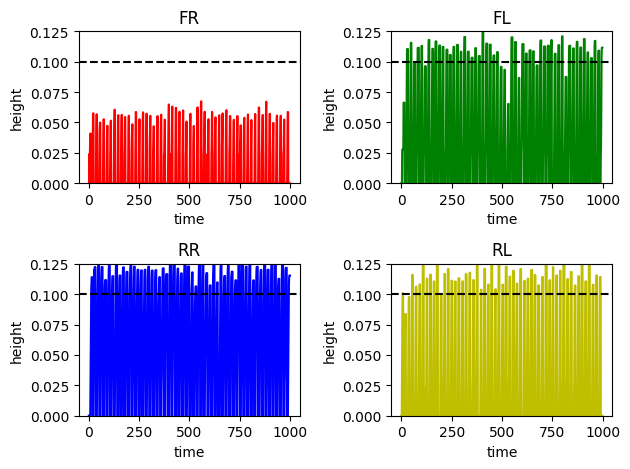

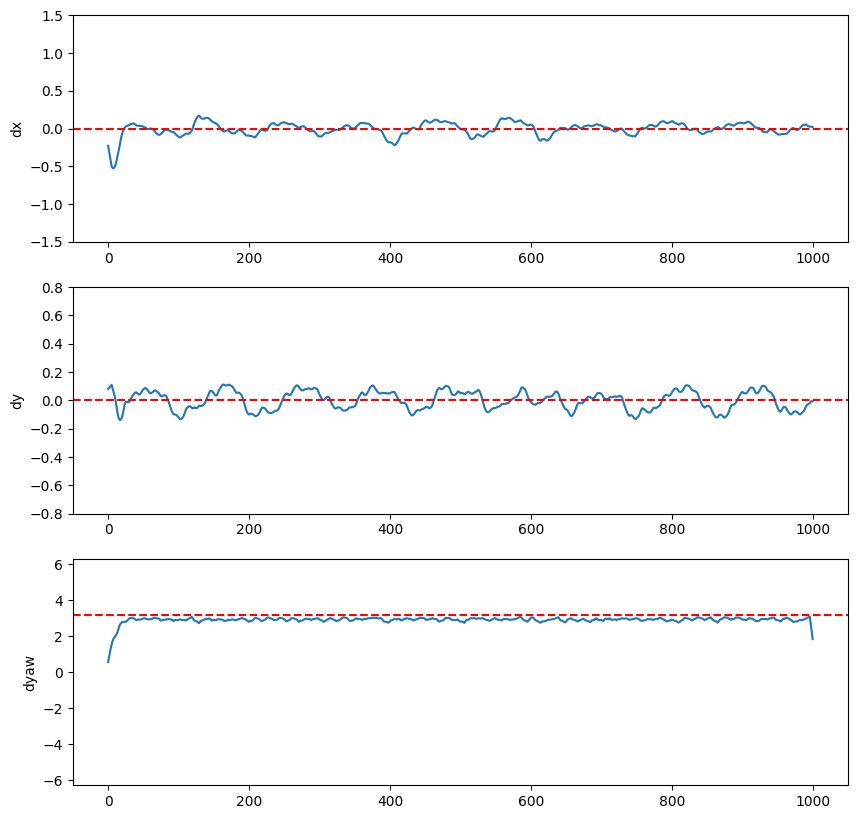

In [23]:
#@title Plot each foot in a 2x2 grid.

swing_peak = jp.array(swing_peak)
names = ["FR", "FL", "RR", "RL"]
colors = ["r", "g", "b", "y"]
fig, axs = plt.subplots(2, 2)
for i, ax in enumerate(axs.flat):
  ax.plot(swing_peak[:, i], color=colors[i])
  ax.set_ylim([0, env_cfg.reward_config.max_foot_height * 1.25])
  ax.axhline(env_cfg.reward_config.max_foot_height, color="k", linestyle="--")
  ax.set_title(names[i])
  ax.set_xlabel("time")
  ax.set_ylabel("height")
plt.tight_layout()
plt.show()

linvel_x = jp.array(linvel)[:, 0]
linvel_y = jp.array(linvel)[:, 1]
angvel_yaw = jp.array(angvel)[:, 2]

# Plot whether velocity is within the command range.
linvel_x = jp.convolve(linvel_x, jp.ones(10) / 10, mode="same")
linvel_y = jp.convolve(linvel_y, jp.ones(10) / 10, mode="same")
angvel_yaw = jp.convolve(angvel_yaw, jp.ones(10) / 10, mode="same")

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(linvel_x)
axes[1].plot(linvel_y)
axes[2].plot(angvel_yaw)

axes[0].set_ylim(
    -env_cfg.command_config.a[0], env_cfg.command_config.a[0]
)
axes[1].set_ylim(
    -env_cfg.command_config.a[1], env_cfg.command_config.a[1]
)
axes[2].set_ylim(
    -env_cfg.command_config.a[2], env_cfg.command_config.a[2]
)

for i, ax in enumerate(axes):
  ax.axhline(state.info["command"][i], color="red", linestyle="--")

labels = ["dx", "dy", "dyaw"]
for i, ax in enumerate(axes):
  ax.set_ylabel(labels[i])

Now let's visualize what it looks like to slowly increase linear velocity commands.

Setting x to 0.0
Setting x to 0.25
Setting x to 0.5
Setting x to 0.75
Setting x to 1.0
Setting x to 1.25
Setting x to 1.5


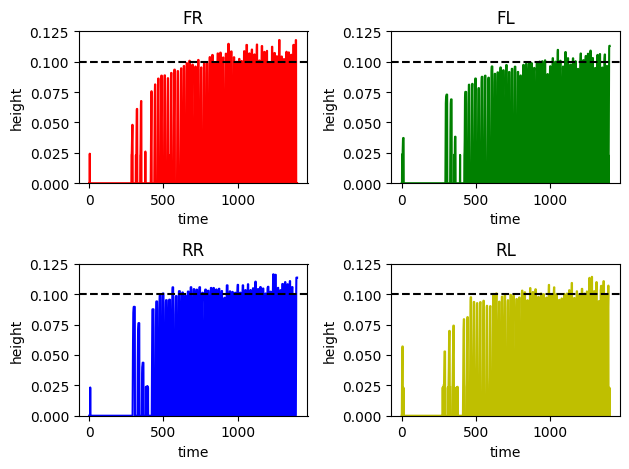

fps: 25.0


100%|██████████| 700/700 [00:05<00:00, 121.90it/s]


This browser does not support the video tag.


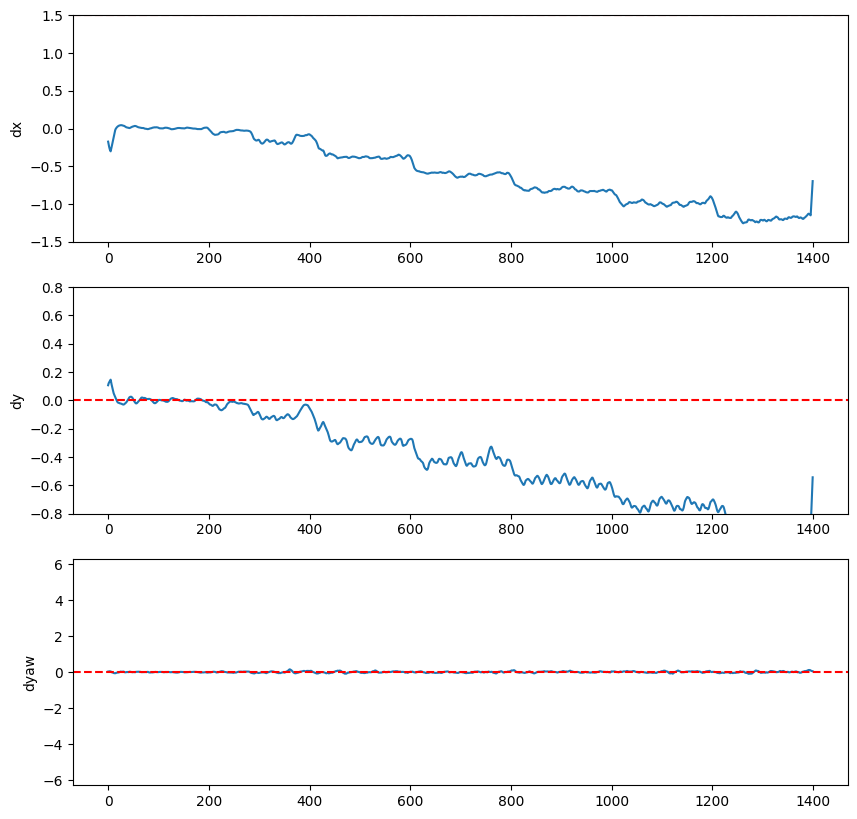

In [24]:
#@title Slowly increase linvel commands

rng = jax.random.PRNGKey(0)
rollout = []
modify_scene_fns = []
swing_peak = []
linvel = []
angvel = []

x = -0.25
command = jp.array([x, 0, 0])
state = jit_reset(rng)
for i in range(1_400):
  # Increase the forward velocity by 0.25 m/s every 200 steps.
  if i % 200 == 0:
    x += 0.25
    print(f"Setting x to {x}")
    command = jp.array([x, 0, 0])
  state.info["command"] = command
  if state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
    rng = sample_pert(rng)
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  rollout.append(state)
  swing_peak.append(state.info["swing_peak"])
  linvel.append(env.get_global_linvel(state.data))
  angvel.append(env.get_gyro(state.data))
  xyz = np.array(state.data.xpos[env._torso_body_id])
  xyz += np.array([0, 0, 0.2])
  x_axis = state.data.xmat[env._torso_body_id, 0]
  yaw = -np.arctan2(x_axis[1], x_axis[0])
  modify_scene_fns.append(
      functools.partial(
          draw_joystick_command,
          cmd=command,
          xyz=xyz,
          theta=yaw,
          scl=abs(command[0]) / env_cfg.command_config.a[0],
      )
  )


# Plot each foot in a 2x2 grid.
swing_peak = jp.array(swing_peak)
names = ["FR", "FL", "RR", "RL"]
colors = ["r", "g", "b", "y"]
fig, axs = plt.subplots(2, 2)
for i, ax in enumerate(axs.flat):
  ax.plot(swing_peak[:, i], color=colors[i])
  ax.set_ylim([0, env_cfg.reward_config.max_foot_height * 1.25])
  ax.axhline(env_cfg.reward_config.max_foot_height, color="k", linestyle="--")
  ax.set_title(names[i])
  ax.set_xlabel("time")
  ax.set_ylabel("height")
plt.tight_layout()
plt.show()

linvel_x = jp.array(linvel)[:, 0]
linvel_y = jp.array(linvel)[:, 1]
angvel_yaw = jp.array(angvel)[:, 2]

# Plot whether velocity is within the command range.
linvel_x = jp.convolve(linvel_x, jp.ones(10) / 10, mode="same")
linvel_y = jp.convolve(linvel_y, jp.ones(10) / 10, mode="same")
angvel_yaw = jp.convolve(angvel_yaw, jp.ones(10) / 10, mode="same")

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(linvel_x)
axes[1].plot(linvel_y)
axes[2].plot(angvel_yaw)

axes[0].set_ylim(
    -env_cfg.command_config.a[0], env_cfg.command_config.a[0]
)
axes[1].set_ylim(
    -env_cfg.command_config.a[1], env_cfg.command_config.a[1]
)
axes[2].set_ylim(
    -env_cfg.command_config.a[2], env_cfg.command_config.a[2]
)

for i, ax in enumerate(axes):
  ax.axhline(state.info["command"][i], color="red", linestyle="--")

labels = ["dx", "dy", "dyaw"]
for i, ax in enumerate(axes):
  ax.set_ylabel(labels[i])


render_every = 2
fps = 1.0 / eval_env.dt / render_every
print(f"fps: {fps}")

traj = rollout[::render_every]
mod_fns = modify_scene_fns[::render_every]
assert len(traj) == len(mod_fns)

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = True

frames = eval_env.render(
    traj,
    camera="track",
    height=480,
    width=640,
    modify_scene_fns=mod_fns,
    scene_option=scene_option,
)
media.show_video(frames, fps=fps, loop=False)